<a href="https://colab.research.google.com/github/ximeniki/Crop-disease-and-pest-detection-AI/blob/main/IP102_Q1098267.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#errasing previous unziped data
!rm -rf /content/dataset
!rm -rf /content/Fruit.zip
!rm -rf /content/__MACOSX

In [ ]:
#install to access drive files + google auth.
!pip install -q pydrive2

import os
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()

#drive conexion configuration
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file_list = drive.ListFile({'q': "title = 'Fruit.zip'"}).GetList()
file_id = file_list[0]['id']
f = drive.CreateFile({'id':file_id})
f.GetContentFile('Fruit.zip')

# unzip file
!unzip -q 'Fruit.zip' -d '/content/dataset'

#data is divided in train and test folders, printing zip content to know which level we are working on
data_dir = '/content/dataset'
print(f"Zip content: {os.listdir(data_dir)}")

Zip content: ['train', 'test']


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,Dense, Dropout, SeparableConv2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#drone architecture
def dron_model(num_clases):
    model = Sequential([
        #standar convolutions
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        #separable layers
        SeparableConv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        SeparableConv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        #parameter reduction
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5), #robustness against noise
        Dense(num_clases, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

train_dir = '/content/dataset/train/train'
val_dir = '/content/dataset/test/test'

#file validation
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Error: training directory not found {train_dir}")

#data augmentation strategy
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.5, 1.5]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_dataset = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_clases = train_dataset.num_classes
model = dron_model(num_clases)
print(f"\nTotal of {num_clases} classes.")
model.summary()

Found 67692 images belonging to 131 classes.
Found 22688 images belonging to 131 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Total of 131 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 109, 109, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 52, 52, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131)            │        16,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,499 (181.64 KB)

 Trainable params: 46,051 (179.89 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#existing train and val routes
train_dir = '/content/dataset/train/train'
val_dir = '/content/dataset/test/test'

if not os.path.isdir(train_dir):
    print(f"Error: Training directory '{train_dir}' not found.")
    print("Please ensure the dataset is unzipped correctly by running the cells above")
    raise FileNotFoundError(f"Training directory '{train_dir}' not found. Please run data setup cells.")

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
)

train_dataset = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

if not os.path.isdir(val_dir):
    print(f"Error: Validation directory '{val_dir}' not found.")
    print("Please ensure the dataset is unzipped correctly by running the cells above")
    raise FileNotFoundError(f"Validation directory '{val_dir}' not found. Please run data setup cells.")

validation_dataset = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

#real class number
num_clases = train_dataset.num_classes
model = dron_model(num_clases)

print(f"\nTotal of {num_clases} classes.")

Found 67692 images belonging to 131 classes.
Found 22688 images belonging to 131 classes.

Total of 131 classes.


Data augmentation example

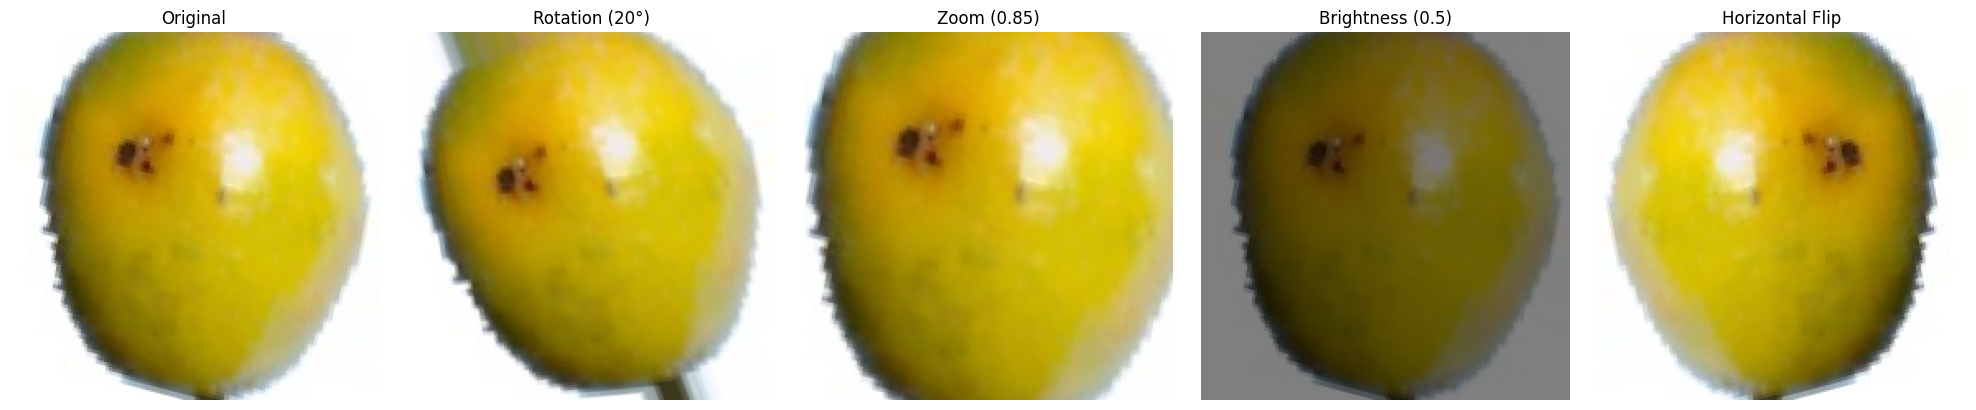

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_dataset)

idx = np.random.randint(0, len(images))
sample_img = images[idx]

titles = ["Original", "Rotation (20°)", "Zoom (0.85)", "Brightness (0.5)", "Horizontal Flip"]
plt.figure(figsize=(20, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    if i == 0:
        display_img = sample_img
    elif i == 1:
        display_img = train_datagen.apply_transform(sample_img, {'theta': 20})
    elif i == 2:
        display_img = train_datagen.apply_transform(sample_img, {'zx': 0.85, 'zy': 0.85})
    elif i == 3:
        display_img = sample_img * 0.5
    elif i == 4:
        display_img = train_datagen.apply_transform(sample_img, {'flip_horizontal': True})

    display_img = np.clip(display_img, 0, 1).astype('float32')
    plt.imshow(display_img)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

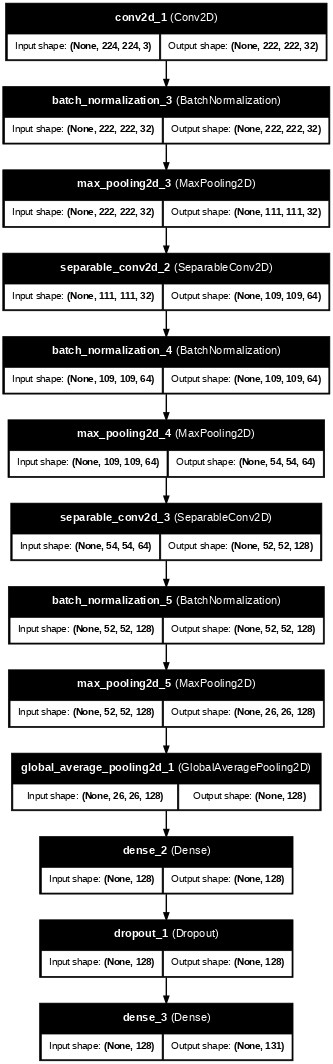

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, dpi=50)

In [ ]:
#ephocs definition if we want a specific number
#EPOCHS = 30
#print(f"Training for {EPOCHS} ephocs...")

#creating 'history' to save data and plot afterwards
#history = model.fit(
    #train_dataset,
    #validation_data=validation_dataset,
    #epochs=EPOCHS,
    #verbose=1 #progress bar
#)


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

#smart epoch callback
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_dron_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=callbacks
)
print("\nTraining completed")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.1290 - loss: 3.9246
Epoch 1: val_loss improved from inf to 1.43362, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 719s 331ms/step - accuracy: 0.1290 - loss: 3.9242 - val_accuracy: 0.7034 - val_loss: 1.4336 - learning_rate: 1.0000e-04
Epoch 2/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.4786 - loss: 1.7774
Epoch 2: val_loss improved from 1.43362 to 0.78568, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 686s 324ms/step - accuracy: 0.4786 - loss: 1.7773 - val_accuracy: 0.8208 - val_loss: 0.7857 - learning_rate: 1.0000e-04
Epoch 3/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.6499 - loss: 1.1375
Epoch 3: val_loss improved from 0.78568 to 0.57424, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 687s 325ms/step - accuracy: 0.6499 - loss: 1.1374 - val_accuracy: 0.8551 - val_loss: 0.5742 - learning_rate: 1.0000e-04
Epoch 4/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7476 - loss: 0.8132
Epoch 4: val_loss improved from 0.57424 to 0.46383, saving model to best_dron_model.h5


...

2116/2116 ━━━━━━━━━━━━━━━━━━━━ 687s 324ms/step - accuracy: 0.8792 - loss: 0.3899 - val_accuracy: 0.9177 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 8/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9015 - loss: 0.3205
Epoch 8: val_loss improved from 0.28382 to 0.27603, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 682s 322ms/step - accuracy: 0.9015 - loss: 0.3205 - val_accuracy: 0.9145 - val_loss: 0.2760 - learning_rate: 1.0000e-04
Epoch 9/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9152 - loss: 0.2719
Epoch 9: val_loss improved from 0.27603 to 0.19314, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 687s 325ms/step - accuracy: 0.9152 - loss: 0.2719 - val_accuracy: 0.9506 - val_loss: 0.1931 - learning_rate: 1.0000e-04
Epoch 10/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9276 - loss: 0.2353
Epoch 10: val_loss did not improve from 0.19314
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 685s 324ms/step - accuracy: 0.9276 - loss: 0.2353 - val_accuracy: 0.8233 - val_loss: 0.5921 - learning_rate: 1.0000e-04
Epoch 11/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9358 - loss: 0.2056
Epoch 11: val_loss did not improve from 0.19314
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 687s 325ms/step - accuracy: 0.9358 - loss: 0.2056 - val_accuracy: 0.9369 - val_loss: 0.2032 - learning_rate: 1.0000e-04
Epoch 12/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9435 - loss: 0.1837
Epoch 12: val_loss improved from 0.19314 to 0.14485, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 684s 323ms/step - accuracy: 0.9435 - loss: 0.1837 - val_accuracy: 0.9602 - val_loss: 0.1449 - learning_rate: 1.0000e-04
Epoch 13/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9498 - loss: 0.1605
Epoch 13: val_loss did not improve from 0.14485
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 684s 323ms/step - accuracy: 0.9498 - loss: 0.1605 - val_accuracy: 0.9503 - val_loss: 0.1669 - learning_rate: 1.0000e-04
Epoch 14/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9547 - loss: 0.1496
Epoch 14: val_loss did not improve from 0.14485
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 685s 324ms/step - accuracy: 0.9547 - loss: 0.1496 - val_accuracy: 0.9545 - val_loss: 0.2036 - learning_rate: 1.0000e-04
Epoch 15/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9561 - loss: 0.1389
Epoch 15: val_loss improved from 0.14485 to 0.13171, saving model to best_dron_model.h5


2116/2116 ━━━━━━━━━━━━━━━━━━━━ 688s 325ms/step - accuracy: 0.9561 - loss: 0.1389 - val_accuracy: 0.9685 - val_loss: 0.1317 - learning_rate: 1.0000e-04
Epoch 16/50
 545/2116 ━━━━━━━━━━━━━━━━━━━━ 8:16 316ms/step - accuracy: 0.9633 - loss: 0.1276

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy - Training', color='green', lw=2)
plt.plot(epochs_range, val_acc, label='Accuracy - Validation', color='lightgreen', lw=2)
plt.title('Model accuracy evolution')
plt.xlabel('Ephocs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

#loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss - Training', color='green', lw=2)
plt.plot(epochs_range, val_loss, label='Loss - Validation', color='lightgreen', lw=2)
plt.title('Model loss accuracy')
plt.xlabel('Ephocs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = list(validation_dataset.class_indices.keys())
validation_dataset.reset()
predictions = model.predict(validation_dataset, verbose=1)
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(25, 20))

sns.heatmap(
    cm_normalized,
    annot=False,
    cmap='magma',
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar_kws={'label': 'Precisión por clase (0.0 a 1.0)'}
)


plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)

plt.title('Matriz de Confusión Normalizada (131 Clases)', fontsize=20)
plt.xlabel('Predicción', fontsize=15)
plt.ylabel('Real', fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


f1 = f1_score(true_labels, predicted_labels, average='weighted')
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')

if len(np.unique(true_labels)) > 2:
    # Multi-class AUC
    true_labels_one_hot = np.eye(len(np.unique(true_labels)))[true_labels]
    roc_auc = roc_auc_score(true_labels_one_hot, predictions, multi_class='ovr')
else:
    # Binary AUC
    roc_auc = roc_auc_score(true_labels, predictions[:,1])

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")